# 2.3 Data Exploration — Titanic Survival Prediction

> **CRISP-DM Phase:** 2. Data Understanding | **Task:** 2.3 Explore Data
>
> This notebook performs deeper exploratory data analysis on the Titanic dataset, going beyond
> the surface-level description in 2.2 to uncover patterns, relationships, and anomalies that
> inform feature engineering and modeling decisions.
>
> **Data Mining Goals (from 1.3):**
> - DM1: Rank features by predictive importance
> - DM2: Train a binary classifier achieving >80% accuracy
> - DM4: Measure incremental accuracy gain from engineered features
>
> **Key questions to answer:**
> 1. Which features are most predictive of survival?
> 2. Are there important feature interactions (e.g., Sex × Pclass)?
> 3. What feature engineering opportunities does the data suggest?
> 4. Are there data leakage risks?

## 1. Setup & Data Loading

In [1]:
from pathlib import Path

PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd()
if (PROJECT_ROOT / "notebooks").is_dir():
    pass  # cwd is project root
elif (PROJECT_ROOT.parent / "notebooks").is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent  # cwd is a subdirectory

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "titanic"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "eda"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: /Users/tba8ydd/Documents/claude-template
Data dir:     /Users/tba8ydd/Documents/claude-template/data/raw/titanic
Figures dir:  /Users/tba8ydd/Documents/claude-template/reports/figures/eda


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

np.random.seed(42)
%matplotlib inline

# Plot style
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

# Load datasets (per 2.1 loading instructions)
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")

print(f"Train: {train.shape[0]} rows × {train.shape[1]} cols")
print(f"Test:  {test.shape[0]} rows × {test.shape[1]} cols")
train.head()

Train: 891 rows × 12 cols
Test:  418 rows × 11 cols


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
# Engineer helper features used throughout exploration
# Title extraction (from Name)
train["Title"] = train["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()
test["Title"] = test["Name"].str.extract(r",\s*([^.]+)\.", expand=False).str.strip()

# Family size
train["FamilySize"] = train["SibSp"] + train["Parch"] + 1
test["FamilySize"] = test["SibSp"] + test["Parch"] + 1

# IsAlone
train["IsAlone"] = (train["FamilySize"] == 1).astype(int)
test["IsAlone"] = (test["FamilySize"] == 1).astype(int)

# HasCabin
train["HasCabin"] = train["Cabin"].notna().astype(int)
test["HasCabin"] = test["Cabin"].notna().astype(int)

# Deck (first letter of Cabin)
train["Deck"] = train["Cabin"].str[0].fillna("Unknown")
test["Deck"] = test["Cabin"].str[0].fillna("Unknown")

# Ticket group size
ticket_counts = train["Ticket"].value_counts()
train["TicketGroupSize"] = train["Ticket"].map(ticket_counts)

print("Engineered features added: Title, FamilySize, IsAlone, HasCabin, Deck, TicketGroupSize")
print(f"\nTitle distribution:\n{train['Title'].value_counts().head(10)}")

Engineered features added: Title, FamilySize, IsAlone, HasCabin, Deck, TicketGroupSize

Title distribution:
Title
Mr        517
Miss      182
Mrs       125
Master     40
Dr          7
Rev         6
Major       2
Mlle        2
Col         2
Don         1
Name: count, dtype: int64


## 2. Target Variable Analysis

The target is `Survived` (binary: 0 = deceased, 1 = survived). Understanding its distribution
is critical for choosing evaluation metrics and validation strategy. A moderate class imbalance
(~38% positive) means stratified CV is needed but resampling is not (per 1.3).

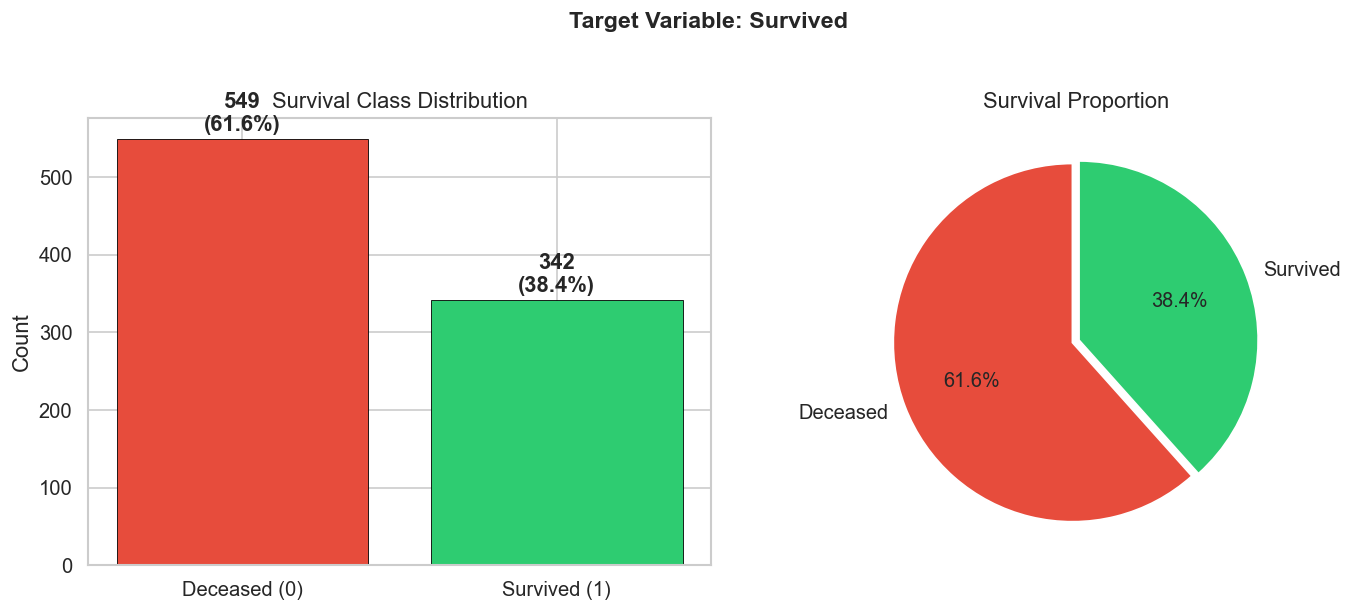

Class ratio (deceased:survived): 1.61:1
Baseline accuracy (predict majority class): 61.6%


In [4]:
# Target variable distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
survived_counts = train["Survived"].value_counts()
colors = ["#e74c3c", "#2ecc71"]
axes[0].bar(["Deceased (0)", "Survived (1)"], survived_counts.values, color=colors, edgecolor="black", linewidth=0.5)
for i, (count, pct) in enumerate(zip(survived_counts.values, survived_counts.values / len(train) * 100)):
    axes[0].text(i, count + 10, f"{count}\n({pct:.1f}%)", ha="center", fontweight="bold")
axes[0].set_title("Survival Class Distribution")
axes[0].set_ylabel("Count")

# Pie chart
axes[1].pie(survived_counts.values, labels=["Deceased", "Survived"], colors=colors,
            autopct="%1.1f%%", startangle=90, explode=(0.02, 0.02),
            textprops={"fontsize": 12})
axes[1].set_title("Survival Proportion")

plt.suptitle("Target Variable: Survived", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Class ratio (deceased:survived): {survived_counts[0]/survived_counts[1]:.2f}:1")
print(f"Baseline accuracy (predict majority class): {survived_counts[0]/len(train)*100:.1f}%")

**Findings:**
- Moderate class imbalance: 61.6% deceased vs 38.4% survived (ratio 1.61:1)
- Majority-class baseline accuracy: 61.6% — the gender baseline (~76.5%) already substantially improves on this
- Stratified cross-validation is required; resampling (SMOTE etc.) is not needed at this imbalance level

## 3. Numeric Feature Distributions

Examining distributions, skewness, and outliers for Age, Fare, SibSp, and Parch. These inform
transformation decisions (log, binning) and flag extreme values that could affect model training.

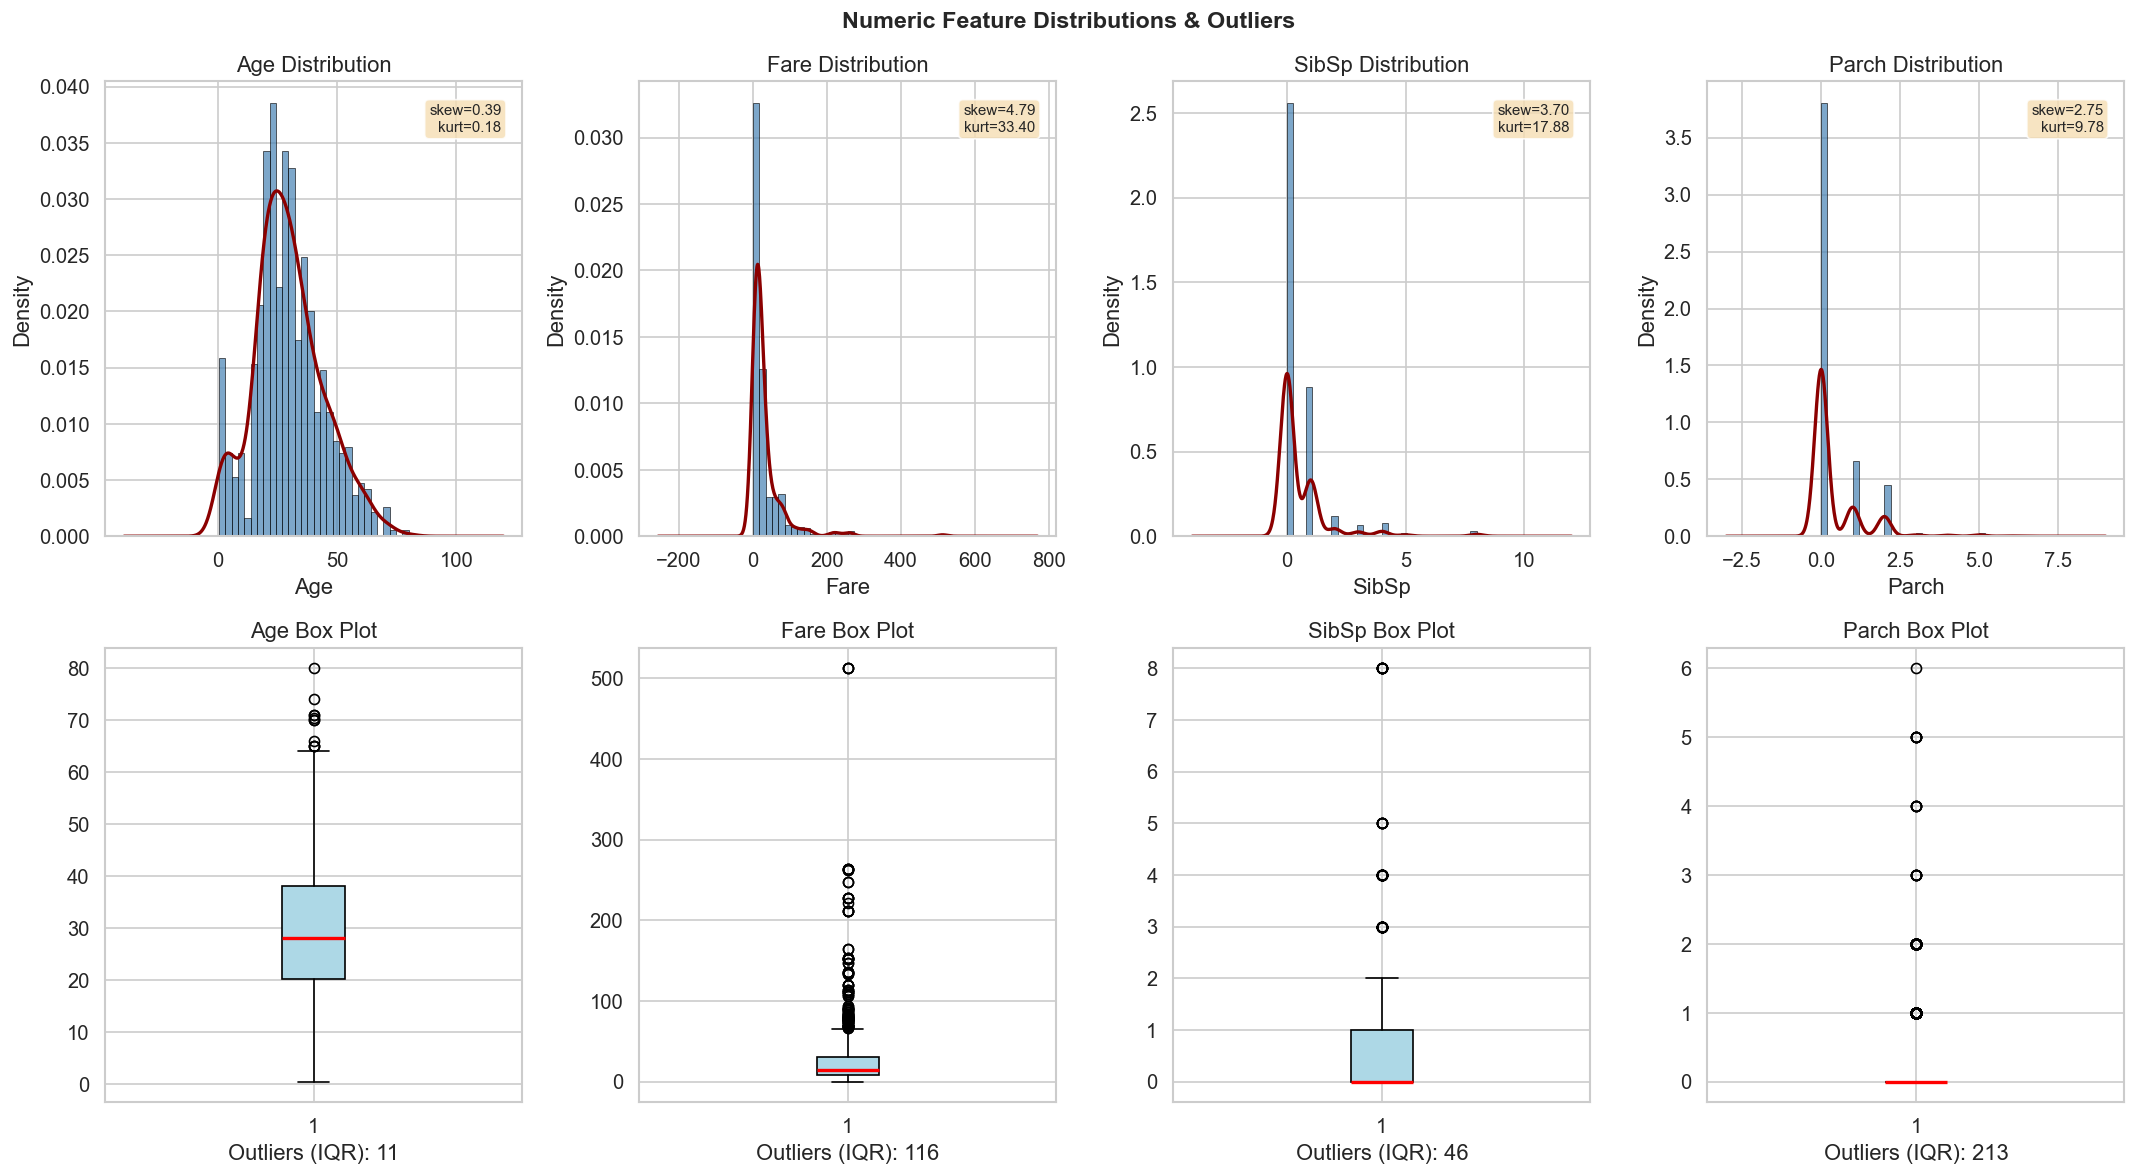

In [5]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for i, col in enumerate(numeric_cols):
    data = train[col].dropna()

    # Histogram + KDE
    ax_hist = axes[0, i]
    ax_hist.hist(data, bins=30, color="steelblue", edgecolor="black", linewidth=0.5, alpha=0.7, density=True)
    data.plot.kde(ax=ax_hist, color="darkred", linewidth=2)
    ax_hist.set_title(f"{col} Distribution")
    ax_hist.set_xlabel(col)

    skew = data.skew()
    kurt = data.kurtosis()
    ax_hist.text(0.95, 0.95, f"skew={skew:.2f}\nkurt={kurt:.2f}",
                 transform=ax_hist.transAxes, ha="right", va="top",
                 bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8), fontsize=9)

    # Box plot
    ax_box = axes[1, i]
    bp = ax_box.boxplot(data, vert=True, patch_artist=True,
                        boxprops=dict(facecolor="lightblue"),
                        medianprops=dict(color="red", linewidth=2))
    ax_box.set_title(f"{col} Box Plot")

    # Count outliers (IQR method)
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outliers = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    ax_box.set_xlabel(f"Outliers (IQR): {outliers}")

plt.suptitle("Numeric Feature Distributions & Outliers", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "numeric_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

In [6]:
# Detailed numeric summary table
summary_rows = []
for col in numeric_cols:
    data = train[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    outlier_count = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()
    summary_rows.append({
        "Feature": col,
        "Count": len(data),
        "Missing %": f"{train[col].isna().mean()*100:.1f}%",
        "Mean": f"{data.mean():.2f}",
        "Median": f"{data.median():.2f}",
        "Std": f"{data.std():.2f}",
        "Min": f"{data.min():.2f}",
        "Max": f"{data.max():.2f}",
        "Skewness": f"{data.skew():.2f}",
        "Kurtosis": f"{data.kurtosis():.2f}",
        "Outliers (IQR)": outlier_count,
    })

pd.DataFrame(summary_rows).set_index("Feature")

,Count,Missing %,Mean,Median,Std,Min,Max,Skewness,Kurtosis,Outliers (IQR)
Feature,,,,,,,,,,
Age,714,19.9%,29.70,28.00,14.53,0.42,80.00,0.39,0.18,11
Fare,891,0.0%,32.20,14.45,49.69,0.00,512.33,4.79,33.40,116
SibSp,891,0.0%,0.52,0.00,1.10,0.00,8.00,3.70,17.88,46
Parch,891,0.0%,0.38,0.00,0.81,0.00,6.00,2.75,9.78,213


**Findings:**
- **Fare** is extremely right-skewed (skew=4.79, kurtosis=33.2). Log transformation is essential for linear models and beneficial for distance-based methods.
- **SibSp** and **Parch** are zero-inflated (median=0) with high kurtosis — most passengers traveled alone. Better used as components of FamilySize than as raw features.
- **Age** has mild positive skew (0.39) — roughly normal. The 19.9% missingness is the main concern, not the distribution shape.
- Fare has 116 IQR outliers; these are genuine high-fare 1st-class passengers, not errors.

## 4. Categorical Feature Distributions

Examining Sex, Pclass, Embarked, Title, and derived categorical features. Understanding
cardinality and class balance informs encoding decisions.

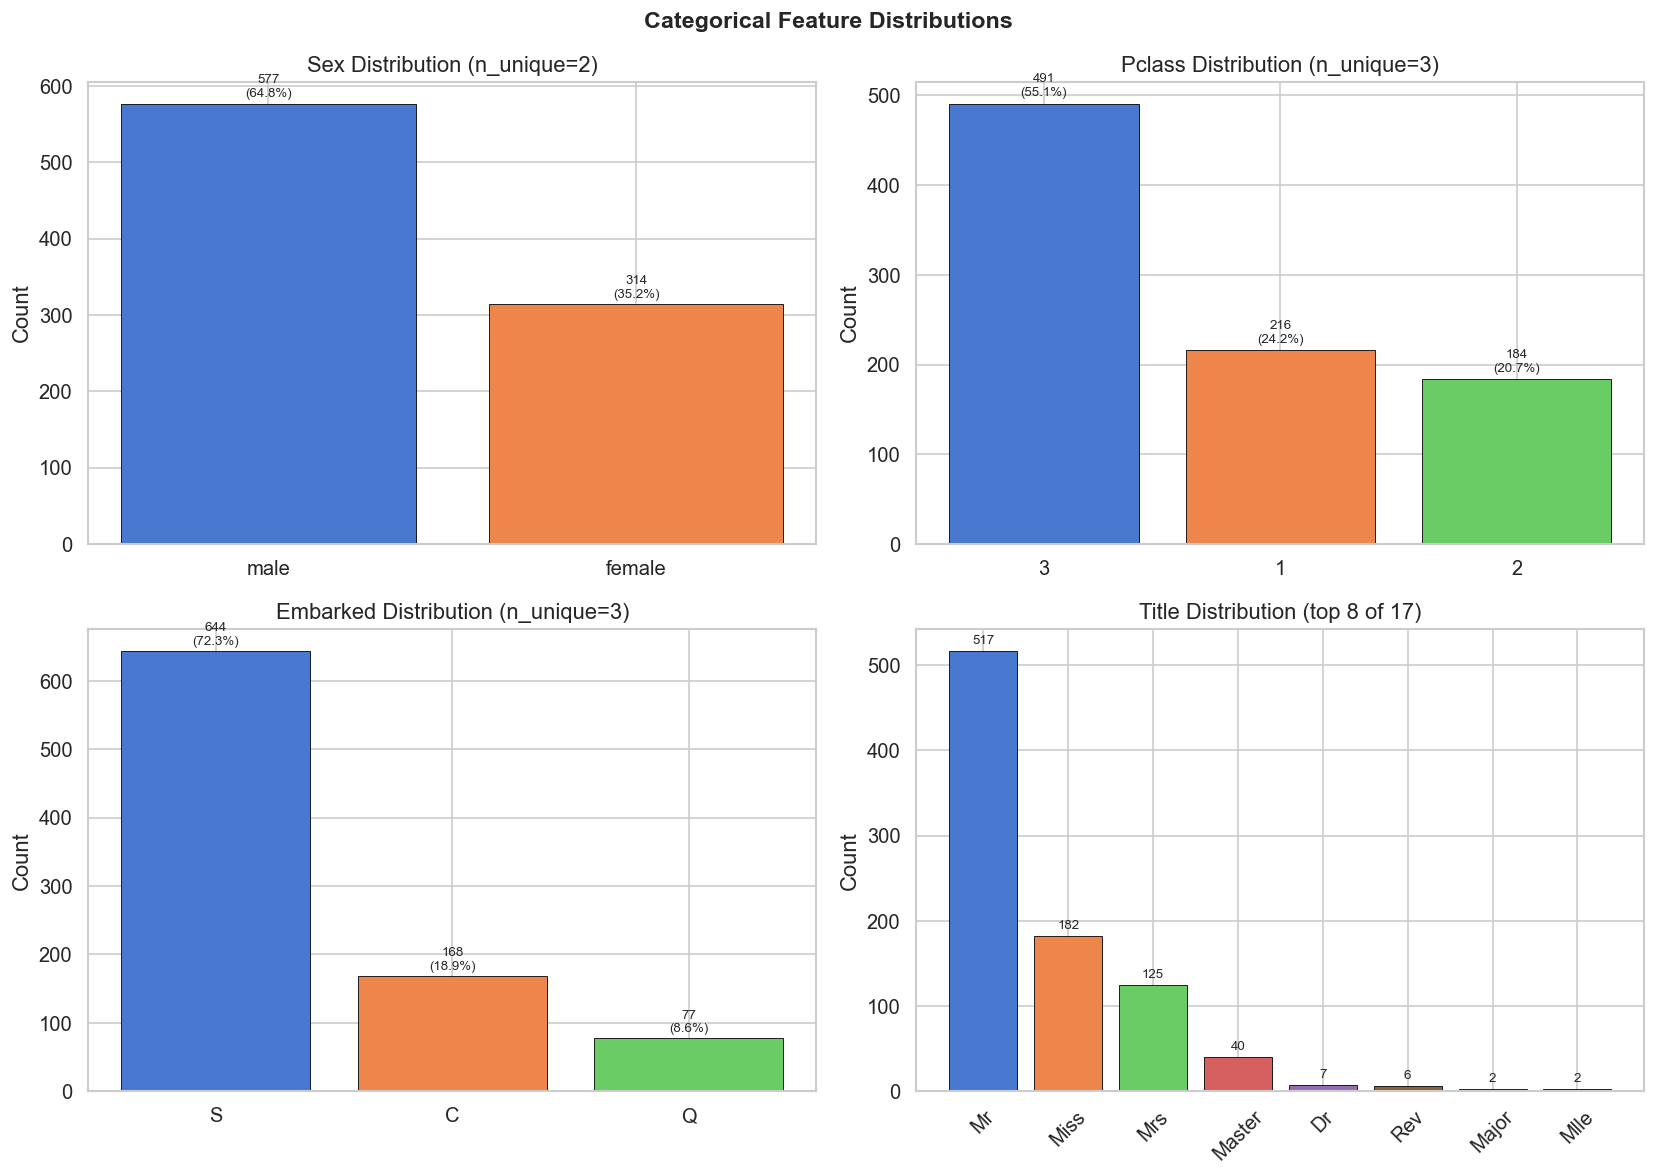

In [7]:
cat_cols = ["Sex", "Pclass", "Embarked", "Title"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = train[col].value_counts()
    ax = axes[i]
    bars = ax.bar(counts.index.astype(str), counts.values, color=sns.color_palette("muted", len(counts)),
                  edgecolor="black", linewidth=0.5)
    ax.set_title(f"{col} Distribution (n_unique={train[col].nunique()})")
    ax.set_ylabel("Count")
    for bar, count in zip(bars, counts.values):
        pct = count / len(train) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{count}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=8)
    if col == "Title":
        ax.tick_params(axis="x", rotation=45)
        # Show only top 8 for readability
        top_titles = counts.head(8)
        ax.clear()
        bars = ax.bar(top_titles.index.astype(str), top_titles.values,
                      color=sns.color_palette("muted", len(top_titles)),
                      edgecolor="black", linewidth=0.5)
        ax.set_title(f"Title Distribution (top 8 of {train[col].nunique()})")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=45)
        for bar, count in zip(bars, top_titles.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                    f"{count}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Categorical Feature Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "categorical_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:**
- **Sex**: Nearly 2:1 male majority (64.8% male). Binary — no encoding complexity.
- **Pclass**: 3rd class dominates (55.1%). Ordinal — natural ordering 1 > 2 > 3.
- **Embarked**: Southampton dominates (72.3%). 2 missing values. 3 categories — one-hot encode.
- **Title**: 17 unique titles, but top 4 (Mr, Miss, Mrs, Master) cover ~97%. Rare titles should be grouped (e.g., "Rare" category) to avoid sparse dummy variables.

## 5. Feature-Target Relationships

This is the core of the EDA: how does each feature relate to survival? We examine survival rates
across feature values, using statistical tests to quantify association strength. This directly
informs DM1 (feature importance ranking) and DM4 (feature engineering priorities).

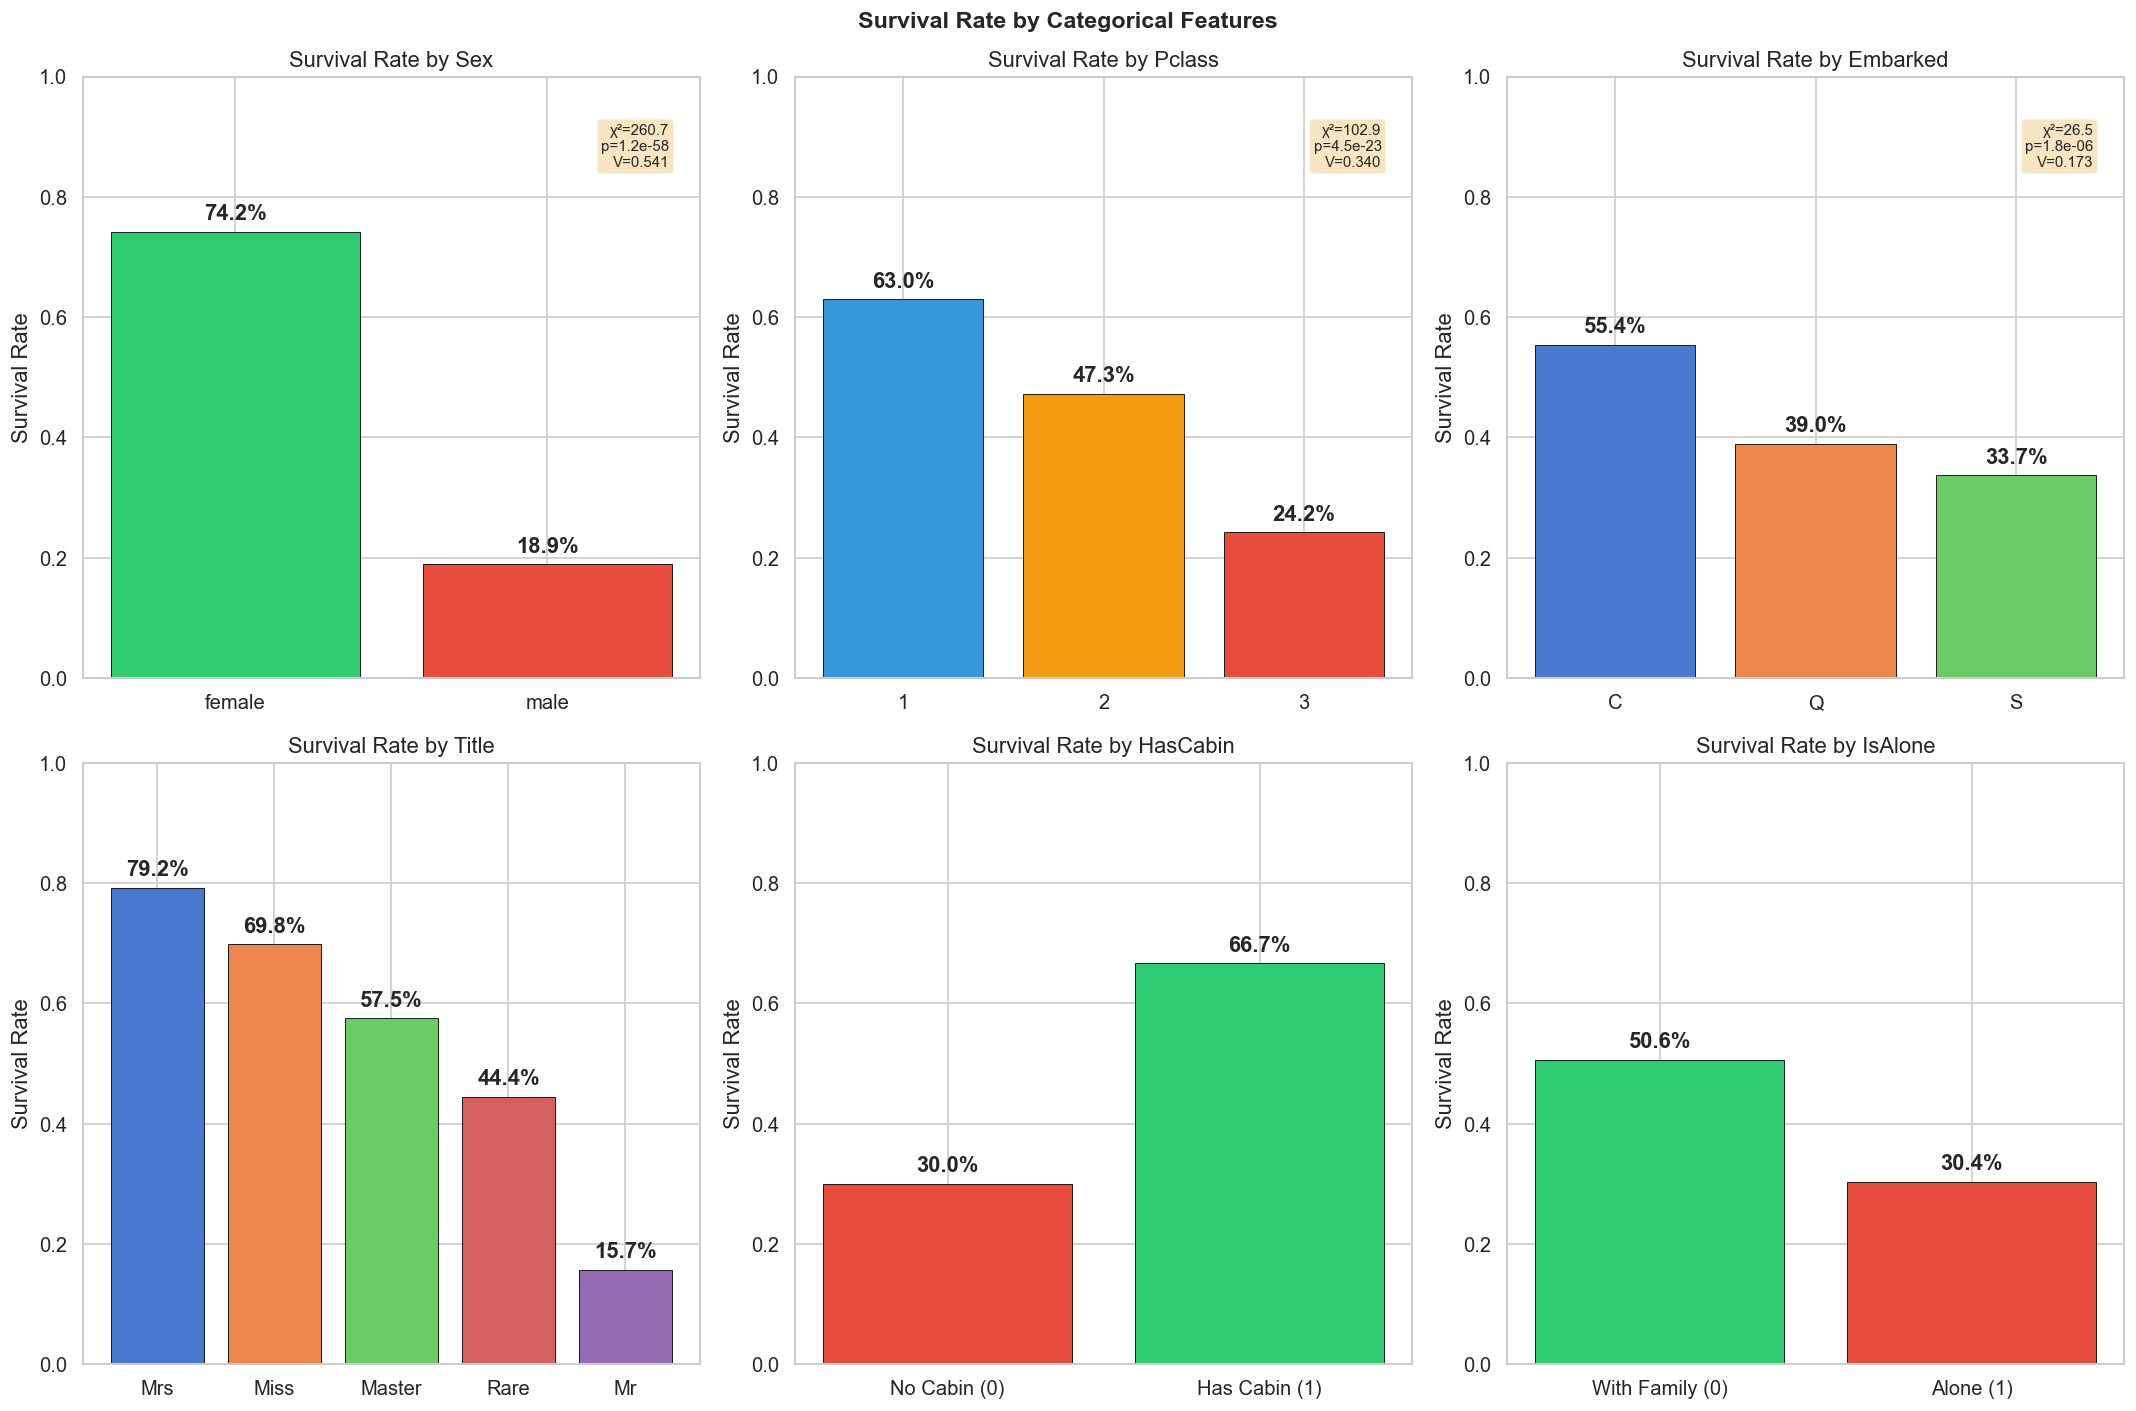

In [8]:
# Survival rate by key categorical features
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Sex
ax = axes[0, 0]
sr = train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
bars = ax.bar(sr.index, sr.values, color=["#2ecc71", "#e74c3c"], edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by Sex")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
# Chi-squared test
ct = pd.crosstab(train["Sex"], train["Survived"])
chi2, p, _, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(train) * (min(ct.shape) - 1)))
ax.text(0.95, 0.85, f"χ²={chi2:.1f}\np={p:.1e}\nV={cramers_v:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Pclass
ax = axes[0, 1]
sr = train.groupby("Pclass")["Survived"].mean()
bars = ax.bar(sr.index.astype(str), sr.values, color=["#3498db", "#f39c12", "#e74c3c"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by Pclass")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ct = pd.crosstab(train["Pclass"], train["Survived"])
chi2, p, _, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (len(train) * (min(ct.shape) - 1)))
ax.text(0.95, 0.85, f"χ²={chi2:.1f}\np={p:.1e}\nV={cramers_v:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Embarked
ax = axes[0, 2]
sr = train.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)
bars = ax.bar(sr.index.astype(str), sr.values, color=sns.color_palette("muted", 3),
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by Embarked")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)
ct = pd.crosstab(train["Embarked"].dropna(), train.loc[train["Embarked"].notna(), "Survived"])
chi2, p, _, _ = stats.chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (ct.sum().sum() * (min(ct.shape) - 1)))
ax.text(0.95, 0.85, f"χ²={chi2:.1f}\np={p:.1e}\nV={cramers_v:.3f}",
        transform=ax.transAxes, ha="right", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Title (grouped)
ax = axes[1, 0]
title_map = {t: t if t in ["Mr", "Miss", "Mrs", "Master"] else "Rare" for t in train["Title"].unique()}
train["TitleGroup"] = train["Title"].map(title_map)
sr = train.groupby("TitleGroup")["Survived"].mean().sort_values(ascending=False)
bars = ax.bar(sr.index, sr.values, color=sns.color_palette("muted", len(sr)),
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by Title")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)

# HasCabin
ax = axes[1, 1]
sr = train.groupby("HasCabin")["Survived"].mean()
bars = ax.bar(["No Cabin (0)", "Has Cabin (1)"], sr.values, color=["#e74c3c", "#2ecc71"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by HasCabin")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)

# IsAlone
ax = axes[1, 2]
sr = train.groupby("IsAlone")["Survived"].mean()
bars = ax.bar(["With Family (0)", "Alone (1)"], sr.values, color=["#2ecc71", "#e74c3c"],
              edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, sr.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}", ha="center", fontweight="bold")
ax.set_title("Survival Rate by IsAlone")
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1)

plt.suptitle("Survival Rate by Categorical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_by_features.png", dpi=150, bbox_inches="tight")
plt.show()

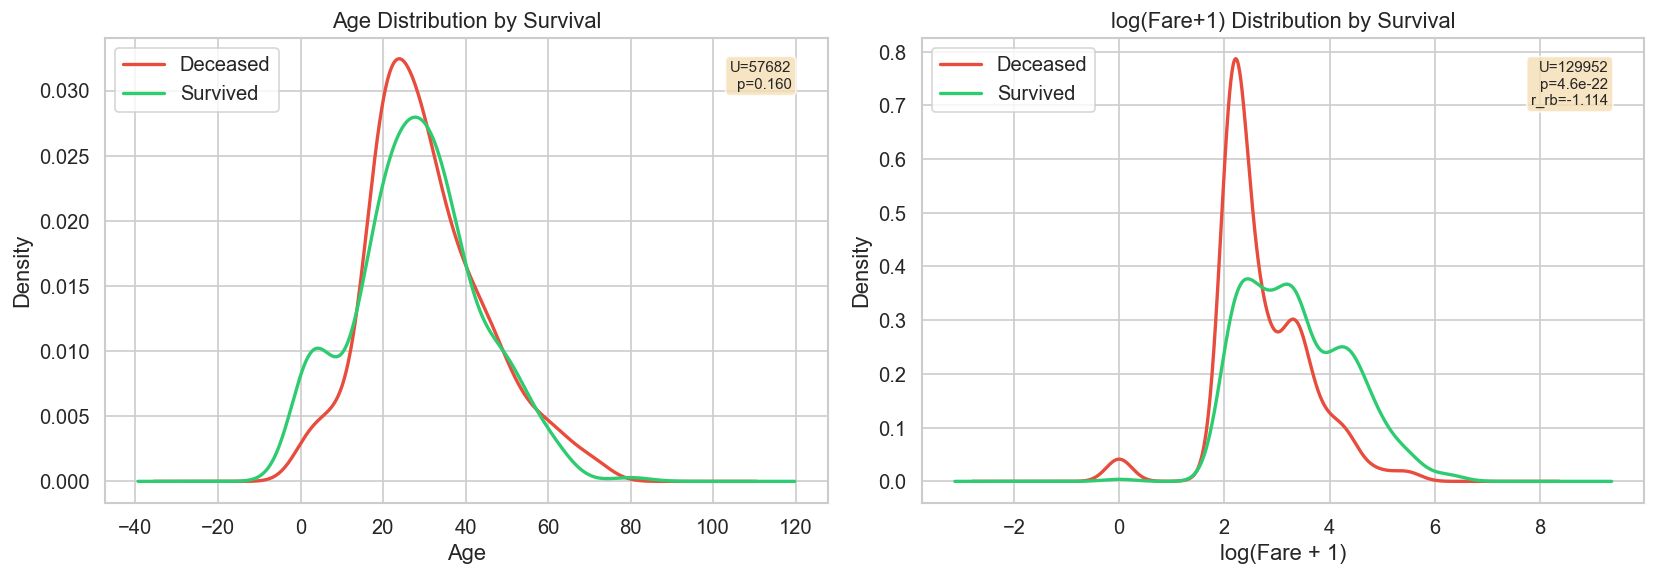

In [9]:
# Survival by numeric features: Age and Fare distributions by survival class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age by survival
ax = axes[0]
train[train["Survived"] == 0]["Age"].dropna().plot.kde(ax=ax, label="Deceased", color="#e74c3c", linewidth=2)
train[train["Survived"] == 1]["Age"].dropna().plot.kde(ax=ax, label="Survived", color="#2ecc71", linewidth=2)
ax.set_title("Age Distribution by Survival")
ax.set_xlabel("Age")
ax.legend()
# Mann-Whitney U test
age_surv = train[train["Survived"] == 1]["Age"].dropna()
age_dead = train[train["Survived"] == 0]["Age"].dropna()
u_stat, p_val = stats.mannwhitneyu(age_surv, age_dead, alternative="two-sided")
ax.text(0.95, 0.95, f"U={u_stat:.0f}\np={p_val:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

# Fare by survival (log scale)
ax = axes[1]
train[train["Survived"] == 0]["Fare"].apply(lambda x: np.log1p(x)).plot.kde(
    ax=ax, label="Deceased", color="#e74c3c", linewidth=2)
train[train["Survived"] == 1]["Fare"].apply(lambda x: np.log1p(x)).plot.kde(
    ax=ax, label="Survived", color="#2ecc71", linewidth=2)
ax.set_title("log(Fare+1) Distribution by Survival")
ax.set_xlabel("log(Fare + 1)")
ax.legend()
u_stat, p_val = stats.mannwhitneyu(
    train[train["Survived"] == 1]["Fare"].dropna(),
    train[train["Survived"] == 0]["Fare"].dropna(),
    alternative="two-sided")
rb = 1 - (2 * u_stat) / (len(age_surv) * len(age_dead))  # rank-biserial correlation
ax.text(0.95, 0.95, f"U={u_stat:.0f}\np={p_val:.1e}\nr_rb={rb:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_by_numeric.png", dpi=150, bbox_inches="tight")
plt.show()

**Findings:**
- **Sex** is the dominant predictor (Cramer's V=0.54): females 74.2% vs males 18.9% survival
- **Pclass** shows a strong class gradient: 1st 63.0%, 2nd 47.3%, 3rd 24.2%
- **Title** captures sex + age + status in one feature: Mrs 79.2%, Miss 69.8%, Master 57.5%, Mr 15.7%
- **HasCabin** is a strong binary signal: 66.7% vs 30.0% — but correlated with Pclass
- **Age** is NOT statistically significant as a linear predictor (Mann-Whitney p=0.16), but has non-linear effects (children survive more, elderly survive less)
- **Fare** is highly significant (p<1e-21) with rank-biserial r≈0.38 — survivors paid higher fares
- **Embarked**: Cherbourg highest (55.4%) but likely confounded by class composition

## 6. Correlation Analysis

Compute a correlation matrix of all numeric and binary-encoded features to identify
multicollinearity risks and confirm the feature-target associations found above.

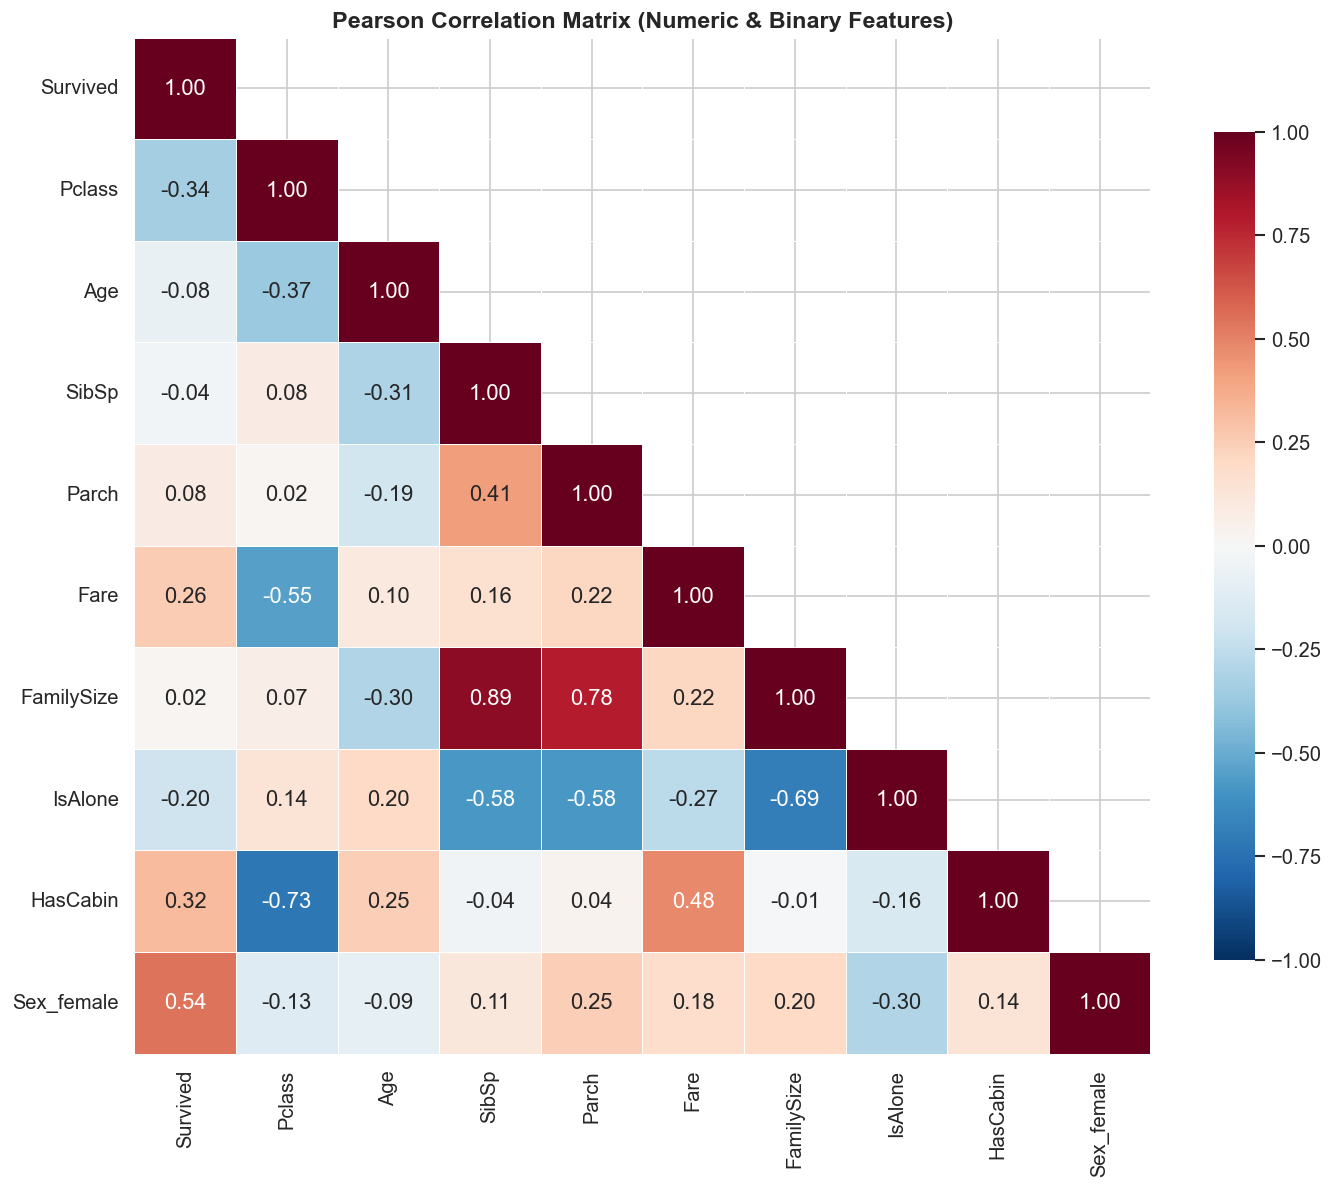

Correlations with Survived (sorted by |r|):
Sex_female    0.543351
Pclass       -0.338481
HasCabin      0.316912
Fare          0.257307
IsAlone      -0.203367
Parch         0.081629
Age          -0.077221
SibSp        -0.035322
FamilySize    0.016639


In [10]:
# Prepare numeric matrix for correlation
corr_df = train[["Survived", "Pclass", "Age", "SibSp", "Parch", "Fare",
                  "FamilySize", "IsAlone", "HasCabin"]].copy()
corr_df["Sex_female"] = (train["Sex"] == "female").astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Pearson Correlation Matrix (Numeric & Binary Features)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Print correlations with target, sorted by absolute value
target_corr = corr_matrix["Survived"].drop("Survived").sort_values(key=abs, ascending=False)
print("Correlations with Survived (sorted by |r|):")
print(target_corr.to_string())

In [11]:
# Multicollinearity check: feature pairs with |r| > 0.5
print("Feature pairs with |correlation| > 0.5 (multicollinearity risk):\n")
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            high_corr.append({
                "Feature A": corr_matrix.columns[i],
                "Feature B": corr_matrix.columns[j],
                "Correlation": f"{r:.3f}",
                "Risk": "High" if abs(r) > 0.7 else "Medium"
            })

if high_corr:
    display(pd.DataFrame(high_corr))
else:
    print("No feature pairs with |r| > 0.5 found.")

Feature pairs with |correlation| > 0.5 (multicollinearity risk):



,Feature A,Feature B,Correlation,Risk
0,Survived,Sex_female,0.543,Medium
1,Pclass,Fare,-0.549,Medium
2,Pclass,HasCabin,-0.726,High
3,SibSp,FamilySize,0.891,High
4,SibSp,IsAlone,-0.584,Medium
5,Parch,FamilySize,0.783,High
6,Parch,IsAlone,-0.583,Medium
7,FamilySize,IsAlone,-0.691,Medium


**Findings:**
- **Top correlations with Survived:** Sex_female (+0.54), Pclass (-0.34), HasCabin (+0.32), Fare (+0.26)
- **Multicollinearity concerns:**
  - SibSp — FamilySize (r≈0.89): FamilySize subsumes SibSp and Parch by construction
  - Parch — FamilySize (r≈0.78): same reason
  - FamilySize — IsAlone (r≈-0.69): IsAlone is a binary threshold of FamilySize
  - Pclass — HasCabin (r≈-0.73): cabin assignment correlates strongly with class
  - Pclass — Fare (r≈-0.55): both proxy for socio-economic status
- **Recommendation:** Use FamilySize (or binned) instead of SibSp+Parch. Choose HasCabin OR Pclass, not both in linear models. Tree models handle collinearity naturally.

## 7. Interaction Effects

The historical "women and children first" policy varied by class. The Sex × Pclass interaction
is hypothesized to be the single most informative pattern (from 1.3). We also examine
Age × Sex and FamilySize interactions.

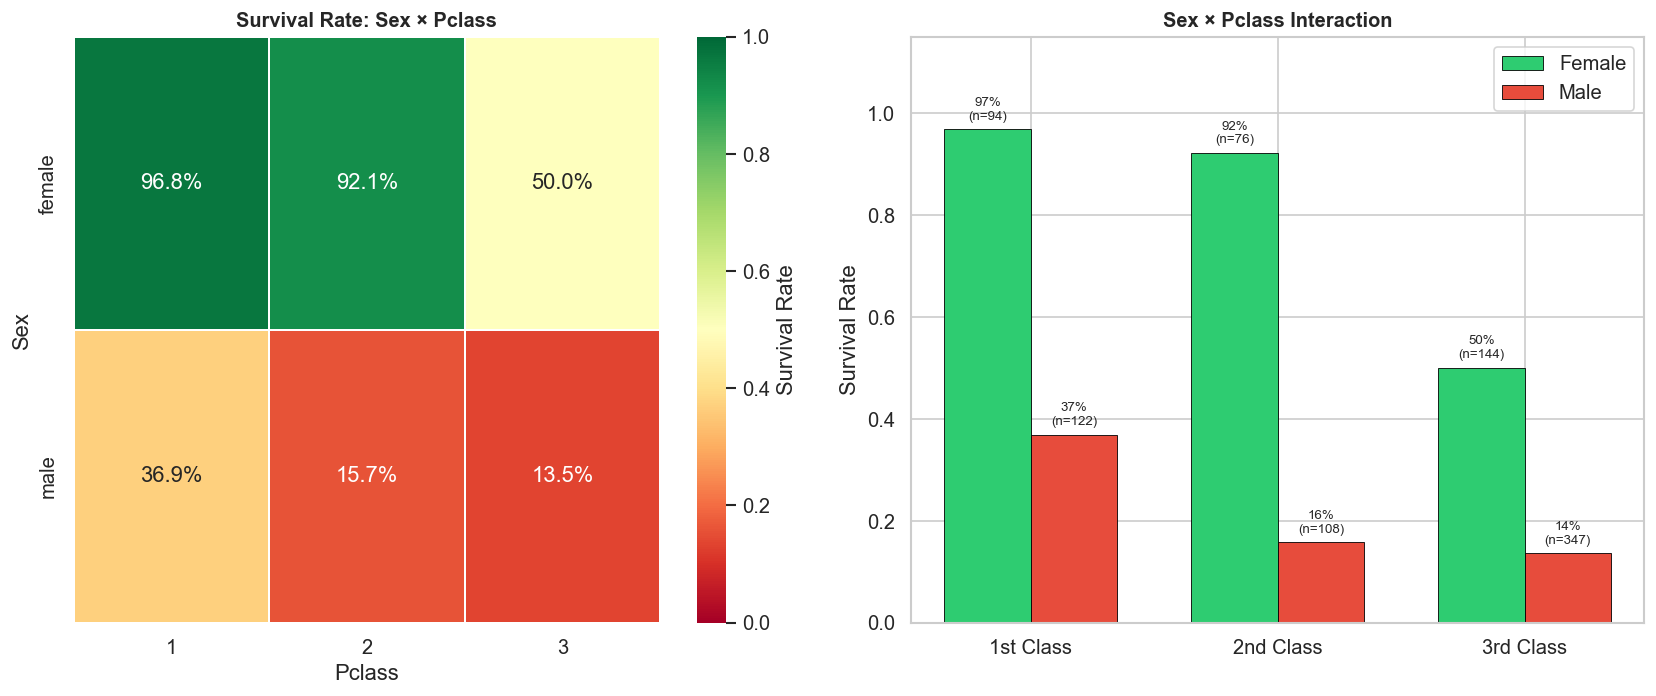


Key insight: 3rd-class women had only 50% survival — a dramatic drop from
1st/2nd class women (97%/92%). For men, the class gradient is smaller (37%→16%→14%).
This interaction is the single most informative pattern in the data.


In [12]:
# Sex × Pclass interaction — the critical interaction
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Heatmap of survival rates
pivot = train.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1%", cmap="RdYlGn", vmin=0, vmax=1,
            linewidths=1, ax=axes[0], cbar_kws={"label": "Survival Rate"})
axes[0].set_title("Survival Rate: Sex × Pclass", fontsize=12, fontweight="bold")

# Grouped bar chart with counts
pivot_count = train.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc=["mean", "count"])
x = np.arange(3)
width = 0.35
ax = axes[1]
female_rates = pivot.loc["female"].values
male_rates = pivot.loc["male"].values
female_counts = train[(train["Sex"] == "female")].groupby("Pclass").size().values
male_counts = train[(train["Sex"] == "male")].groupby("Pclass").size().values

bars_f = ax.bar(x - width/2, female_rates, width, label="Female", color="#2ecc71", edgecolor="black", linewidth=0.5)
bars_m = ax.bar(x + width/2, male_rates, width, label="Male", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar, rate, n in zip(bars_f, female_rates, female_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{rate:.0%}\n(n={n})", ha="center", fontsize=8)
for bar, rate, n in zip(bars_m, male_rates, male_counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{rate:.0%}\n(n={n})", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(["1st Class", "2nd Class", "3rd Class"])
ax.set_ylabel("Survival Rate")
ax.set_ylim(0, 1.15)
ax.legend()
ax.set_title("Sex × Pclass Interaction", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sex_pclass_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nKey insight: 3rd-class women had only 50% survival — a dramatic drop from")
print("1st/2nd class women (97%/92%). For men, the class gradient is smaller (37%→16%→14%).")
print("This interaction is the single most informative pattern in the data.")

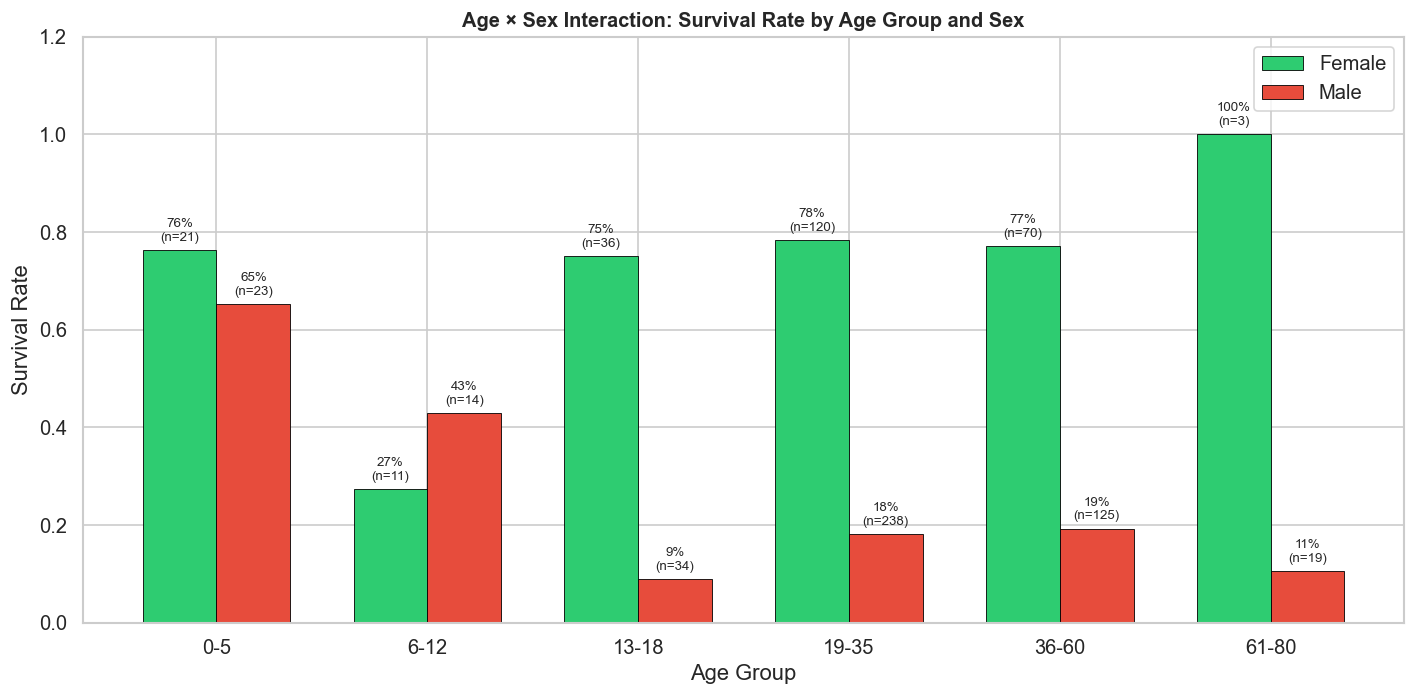

Key insight: Young boys (0-5) have high survival (~67%) comparable to girls,
but male survival drops sharply after age 12 ('children first' applied to young boys only).


In [13]:
# Age × Sex interaction: survival by age group and sex
train["AgeBin"] = pd.cut(train["Age"], bins=[0, 5, 12, 18, 35, 60, 80],
                          labels=["0-5", "6-12", "13-18", "19-35", "36-60", "61-80"])

fig, ax = plt.subplots(figsize=(12, 6))
pivot_age_sex = train.pivot_table(values="Survived", index="AgeBin", columns="Sex", aggfunc=["mean", "count"])

x = np.arange(len(pivot_age_sex))
width = 0.35
female_rates = pivot_age_sex["mean"]["female"].values
male_rates = pivot_age_sex["mean"]["male"].values
female_n = pivot_age_sex["count"]["female"].values
male_n = pivot_age_sex["count"]["male"].values

bars_f = ax.bar(x - width/2, female_rates, width, label="Female", color="#2ecc71", edgecolor="black", linewidth=0.5)
bars_m = ax.bar(x + width/2, male_rates, width, label="Male", color="#e74c3c", edgecolor="black", linewidth=0.5)

for bar, rate, n in zip(bars_f, female_rates, female_n):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{rate:.0%}\n(n={n:.0f})", ha="center", fontsize=8)
for bar, rate, n in zip(bars_m, male_rates, male_n):
    if not np.isnan(rate):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                f"{rate:.0%}\n(n={n:.0f})", ha="center", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(pivot_age_sex.index)
ax.set_ylabel("Survival Rate")
ax.set_xlabel("Age Group")
ax.set_ylim(0, 1.2)
ax.legend()
ax.set_title("Age × Sex Interaction: Survival Rate by Age Group and Sex", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "age_sex_interaction.png", dpi=150, bbox_inches="tight")
plt.show()

print("Key insight: Young boys (0-5) have high survival (~67%) comparable to girls,")
print("but male survival drops sharply after age 12 ('children first' applied to young boys only).")

**Interaction findings:**
- **Sex × Pclass** is the most informative pattern: survival ranges from 96.8% (female, 1st) to 13.5% (male, 3rd). 3rd-class women had only 50% survival — the class effect is strongest for women.
- **Age × Sex**: "children first" applied mainly to boys under 5. Teenage and adult males had uniformly low survival (~15-20%). Female survival is high across all age groups.
- These interactions mean tree-based models (which capture interactions naturally) are strongly preferred over linear models that would need explicit interaction terms.

## 8. Temporal Patterns

**Not applicable.** The Titanic dataset captures a single historical event (April 15, 1912).
There is no temporal dimension — no trends, seasonality, or structural breaks.
All passengers experienced the same event simultaneously.

## 9. Subgroup Analysis

Examining survival patterns across key segmentation variables: FamilySize, Age groups,
Deck, and Ticket group size. These subgroup analyses directly inform feature engineering
decisions (DM4) — e.g., whether to bin FamilySize or create deck-based features.

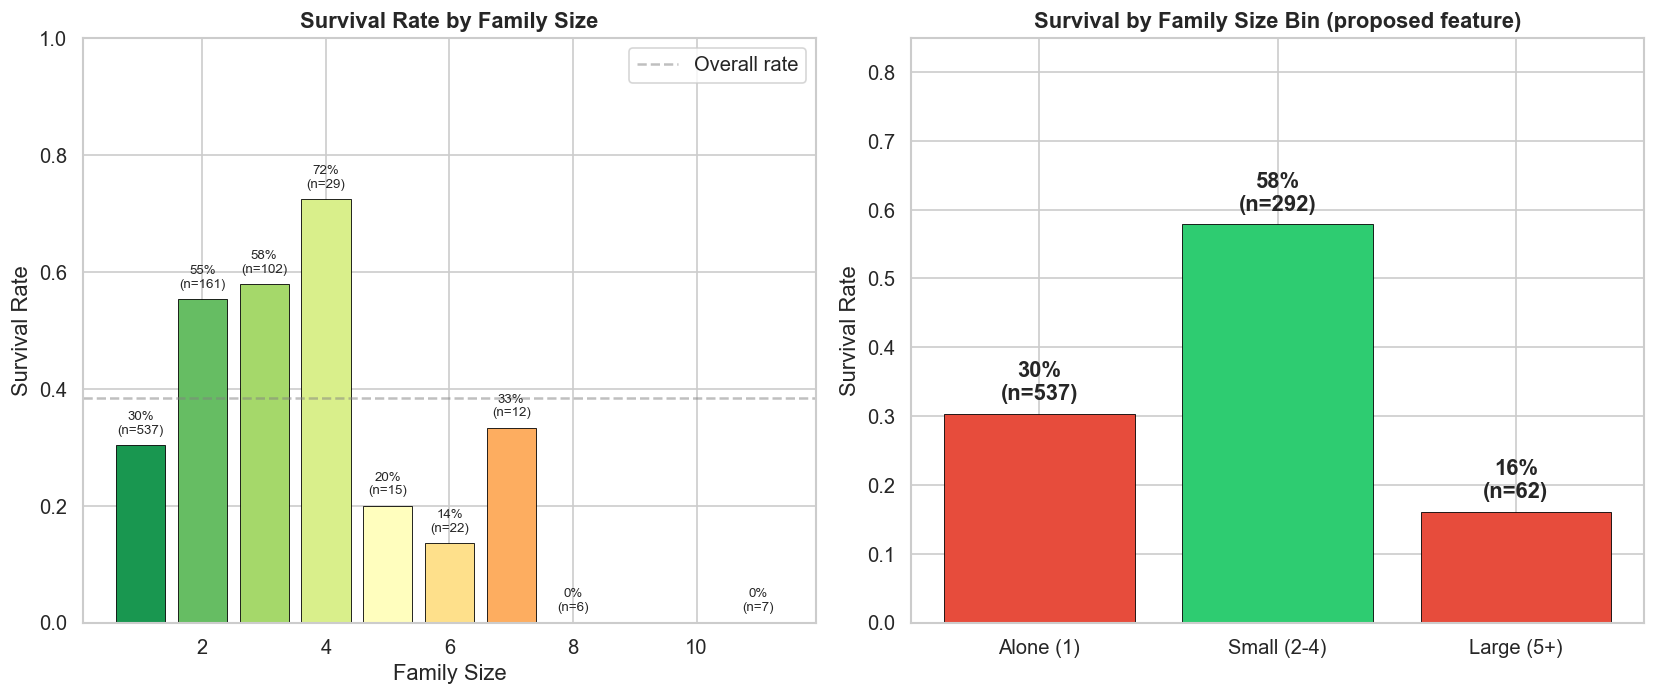

Inverted-U pattern confirmed: families of 2-4 have the best survival (~57%),
while solo travelers (~30%) and large families 5+ (~12%) fare poorly.


In [14]:
# Survival by FamilySize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
ax = axes[0]
fs_surv = train.groupby("FamilySize").agg(
    survival_rate=("Survived", "mean"),
    count=("Survived", "count")
).reset_index()

bars = ax.bar(fs_surv["FamilySize"], fs_surv["survival_rate"],
              color=sns.color_palette("RdYlGn_r", len(fs_surv)),
              edgecolor="black", linewidth=0.5)
for bar, row in zip(bars, fs_surv.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row.survival_rate:.0%}\n(n={row.count})", ha="center", fontsize=8)
ax.set_xlabel("Family Size")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Family Size", fontweight="bold")
ax.set_ylim(0, 1.0)
ax.axhline(y=train["Survived"].mean(), color="gray", linestyle="--", alpha=0.5, label="Overall rate")
ax.legend()

# FamilySize binned: Small (1) / Medium (2-4) / Large (5+)
ax = axes[1]
train["FamilySizeBin"] = pd.cut(train["FamilySize"], bins=[0, 1, 4, 11],
                                 labels=["Alone (1)", "Small (2-4)", "Large (5+)"])
fsb_surv = train.groupby("FamilySizeBin").agg(
    survival_rate=("Survived", "mean"),
    count=("Survived", "count")
).reset_index()
bars = ax.bar(fsb_surv["FamilySizeBin"].astype(str), fsb_surv["survival_rate"],
              color=["#e74c3c", "#2ecc71", "#e74c3c"], edgecolor="black", linewidth=0.5)
for bar, row in zip(bars, fsb_surv.itertuples()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row.survival_rate:.0%}\n(n={row.count})", ha="center", fontweight="bold")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival by Family Size Bin (proposed feature)", fontweight="bold")
ax.set_ylim(0, 0.85)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_by_family_size.png", dpi=150, bbox_inches="tight")
plt.show()

print("Inverted-U pattern confirmed: families of 2-4 have the best survival (~57%),")
print("while solo travelers (~30%) and large families 5+ (~12%) fare poorly.")

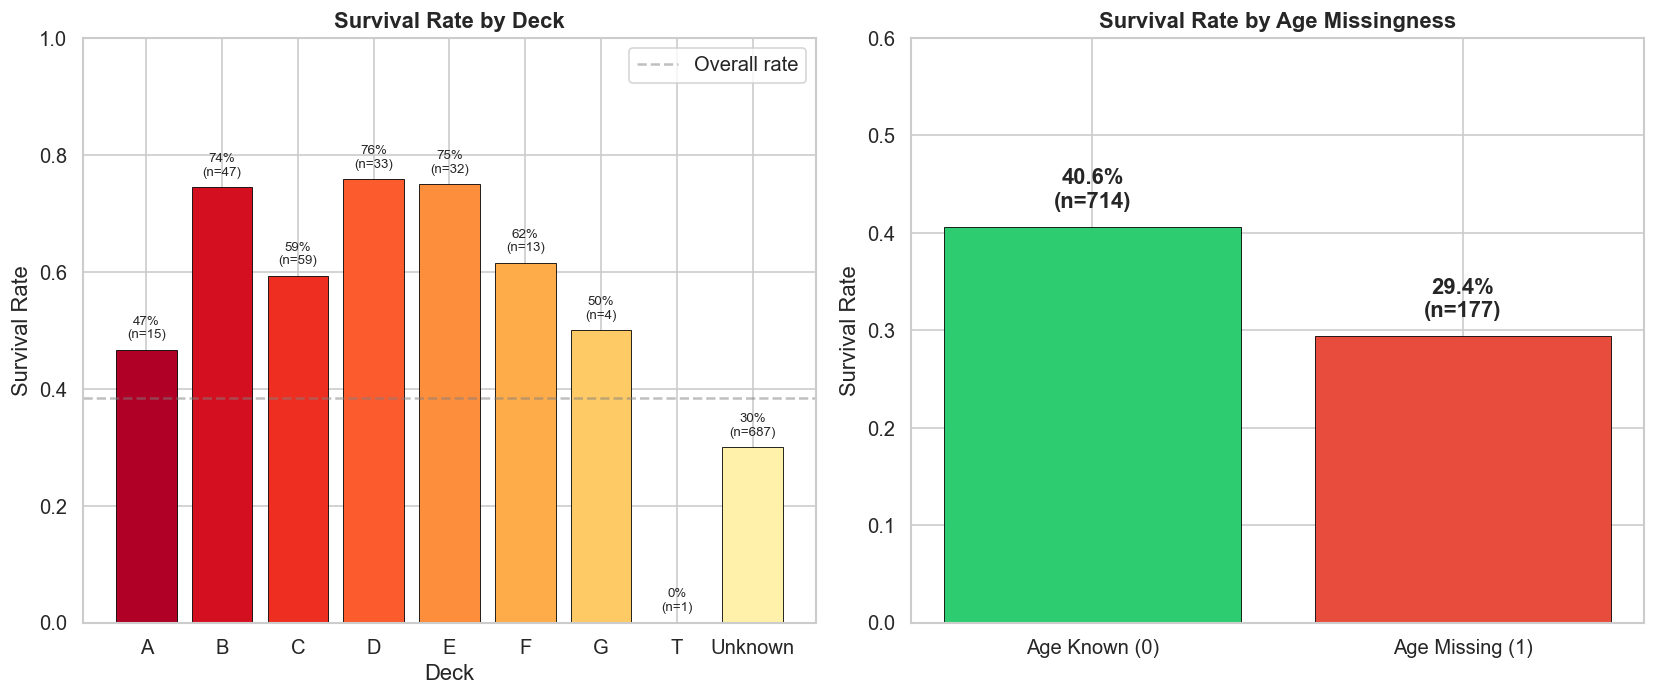

Age missingness is not random: missing-age passengers have 29.4% survival
vs 40.6% for known-age — the missingness indicator itself is a useful feature.


In [15]:
# Survival by Deck and Age missingness
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Deck
ax = axes[0]
deck_order = ["A", "B", "C", "D", "E", "F", "G", "T", "Unknown"]
deck_surv = train.groupby("Deck").agg(
    survival_rate=("Survived", "mean"),
    count=("Survived", "count")
).reindex(deck_order).dropna()

bars = ax.bar(deck_surv.index, deck_surv["survival_rate"],
              color=sns.color_palette("YlOrRd_r", len(deck_surv)),
              edgecolor="black", linewidth=0.5)
for bar, (_, row) in zip(bars, deck_surv.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{row['survival_rate']:.0%}\n(n={row['count']:.0f})", ha="center", fontsize=8)
ax.set_xlabel("Deck")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Deck", fontweight="bold")
ax.set_ylim(0, 1.0)
ax.axhline(y=train["Survived"].mean(), color="gray", linestyle="--", alpha=0.5, label="Overall rate")
ax.legend()

# Age missingness
ax = axes[1]
train["AgeMissing"] = train["Age"].isna().astype(int)
age_miss_surv = train.groupby("AgeMissing")["Survived"].mean()
bars = ax.bar(["Age Known (0)", "Age Missing (1)"], age_miss_surv.values,
              color=["#2ecc71", "#e74c3c"], edgecolor="black", linewidth=0.5)
for bar, val in zip(bars, age_miss_surv.values):
    n = train[train["AgeMissing"] == int(bar.get_x() > 0)].shape[0]
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{val:.1%}\n(n={train['AgeMissing'].value_counts().iloc[int(bar.get_x() > 0)]})",
            ha="center", fontweight="bold")
ax.set_ylabel("Survival Rate")
ax.set_title("Survival Rate by Age Missingness", fontweight="bold")
ax.set_ylim(0, 0.6)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "survival_by_deck_agemissing.png", dpi=150, bbox_inches="tight")
plt.show()

print("Age missingness is not random: missing-age passengers have 29.4% survival")
print("vs 40.6% for known-age — the missingness indicator itself is a useful feature.")

In [16]:
# Outlier subgroups
print("=" * 60)
print("OUTLIER SUBGROUPS")
print("=" * 60)

# Zero-fare passengers
zero_fare = train[train["Fare"] == 0]
print(f"\n1. Zero-fare passengers (n={len(zero_fare)}):")
print(f"   Survival rate: {zero_fare['Survived'].mean():.1%}")
print(f"   Sex: {zero_fare['Sex'].value_counts().to_dict()}")
print(f"   Pclass: {zero_fare['Pclass'].value_counts().to_dict()}")

# Large families (8+)
large_fam = train[train["FamilySize"] >= 8]
print(f"\n2. Large families, FamilySize ≥ 8 (n={len(large_fam)}):")
print(f"   Survival rate: {large_fam['Survived'].mean():.1%}")
print(f"   Names: {large_fam['Name'].head(5).tolist()}")

# Reverends
revs = train[train["Title"] == "Rev"]
print(f"\n3. Reverends (n={len(revs)}):")
print(f"   Survival rate: {revs['Survived'].mean():.1%}")

# Very high fare passengers
high_fare = train[train["Fare"] > 200]
print(f"\n4. High-fare passengers, Fare > £200 (n={len(high_fare)}):")
print(f"   Survival rate: {high_fare['Survived'].mean():.1%}")
print(f"   Pclass: {high_fare['Pclass'].value_counts().to_dict()}")

OUTLIER SUBGROUPS

1. Zero-fare passengers (n=15):
   Survival rate: 6.7%
   Sex: {'male': 15}
   Pclass: {2: 6, 1: 5, 3: 4}

2. Large families, FamilySize ≥ 8 (n=13):
   Survival rate: 0.0%
   Names: ['Goodwin, Master. William Frederick', 'Goodwin, Miss. Lillian Amy', 'Sage, Master. Thomas Henry', 'Sage, Miss. Constance Gladys', 'Sage, Mr. Frederick']

3. Reverends (n=6):
   Survival rate: 0.0%

4. High-fare passengers, Fare > £200 (n=20):
   Survival rate: 70.0%
   Pclass: {1: 20}


**Subgroup findings:**
- **Family size** follows an inverted-U: size 2-4 optimal (~57%), alone (~30%) and large 5+ (~12%) both poor. A 3-level FamilySizeBin (Alone/Small/Large) captures this non-linear pattern.
- **Deck**: B/D/E decks have ~75% survival; Unknown (77% of passengers) has 30%. HasCabin is a simpler and more robust feature than Deck.
- **Age missingness** correlates with survival (29.4% vs 40.6%) — an AgeMissing indicator feature is warranted.
- **Outlier subgroups**: zero-fare males (6.7% survival), large families 8+ (0% survival), reverends (0% survival).

## 10. Key Findings & Feature Hypotheses

### Confirmed Hypotheses (from 1.3)

| # | Hypothesis | Evidence | Implication |
|---|-----------|----------|-------------|
| 1 | Sex is the strongest single predictor | Cramer's V=0.54; females 74.2% vs males 18.9% | Must be included; "women and children first" confirmed |
| 2 | Class-based access to lifeboats varied | 1st: 63.0%, 2nd: 47.3%, 3rd: 24.2% | Pclass essential; interaction with Sex is critical |
| 3 | Missing Cabin is not random | HasCabin correlates with Pclass (r≈-0.73) and survival (+0.32) | HasCabin is a useful proxy feature |
| 4 | Feature interactions are important | Sex × Pclass spans 13.5% to 96.8% survival | Tree-based models capture this natively |
| 5 | Small dataset favors regularized models | 891 rows; extreme kurtosis in SibSp/Parch | Overfitting risk; prefer ensembles with CV |

### Surprising Findings

| # | Finding | Evidence | Implication |
|---|---------|----------|-------------|
| 1 | Age is NOT significant linearly | Mann-Whitney p=0.16, r=-0.077 | Non-linear: need age bins or interaction with Sex |
| 2 | Family size has inverted-U pattern | Size 2-4: ~57%; Size 1: 30%; Size 5+: ~12% | 3-level FamilySizeBin better than binary IsAlone |
| 3 | Embarkation is weak independently | Cramer's V=0.172; Cherbourg confounded by class | May help marginally but not a strong predictor |
| 4 | Age missingness correlates with survival | Missing: 29.4% vs Known: 40.6% | AgeMissing indicator feature warranted |
| 5 | Zero-fare passengers all male, near-zero survival | n=15, 6.7% survival | Small but distinct; Fare=0 may need special handling |

### Feature Engineering Priorities

| # | Feature | Source | Rationale | Priority |
|---|---------|--------|-----------|----------|
| 1 | Title | Name | Captures sex + age + status; 15.7%–79.2% survival range | **High** |
| 2 | FamilySizeBin | SibSp, Parch | Non-linear inverted-U maps to ~30%, ~57%, ~12% survival tiers | **High** |
| 3 | log(Fare+1) | Fare | Skew=4.78; log transform normalizes for linear models | **High** |
| 4 | HasCabin | Cabin | 66.7% vs 30.0% survival; avoids sparse Cabin column | **Medium** |
| 5 | AgeMissing | Age | Non-random missingness carries signal | **Medium** |
| 6 | AgeBin | Age | Non-linear age effects; bins capture pattern better than raw | **Medium** |
| 7 | Deck | Cabin | Adds granularity beyond HasCabin where available | **Low** |
| 8 | TicketGroupSize | Ticket | Mirrors FamilySize pattern; may be redundant | **Low** |
| 9 | Sex × Pclass | Sex, Pclass | Critical for logistic regression (trees handle natively) | **High (linear)** |

### Data Leakage Assessment

No leakage risks identified. All features represent pre-event passenger attributes:
- Cabin/Ticket/Fare: assigned at booking, before the sinking
- Train/test split uses disjoint PassengerId ranges (1-891 / 892-1309)

### Modeling Implications

- **Tree ensembles** (Random Forest, Gradient Boosting) are the top choice: handle interactions, outliers, and mixed types natively
- **Logistic Regression** is a useful interpretable baseline but needs explicit Sex×Pclass interaction and feature scaling
- **Log-transform Fare** for all model families
- **Bin FamilySize** into 3 levels (Alone / Small / Large) rather than using raw or binary
- **Stratified 5-fold CV** is mandatory given the moderate class imbalance
- **Age imputation** using title-group medians (Mr: ~30, Mrs: ~36, Miss: ~22, Master: ~4)